In [1]:
import random
import time
import math
from multiprocessing import Pool


def monte_carlo_part(num_samples):
    inside_circle = 0
    for _ in range(num_samples):
        x = random.random()
        y = random.random()
        if x*x + y*y <= 1:
            inside_circle += 1
    return inside_circle


def calculate_pi_parallel(total_samples, num_processes):
    samples_per_process = total_samples // num_processes

    with Pool(processes=num_processes) as pool:
        results = pool.map(monte_carlo_part, [samples_per_process] * num_processes)

    total_inside = sum(results)
    return 4 * total_inside / total_samples


# ========================
# EKSPERIMEN
# ========================

total_samples = 10_000_000
thread_counts = [1, 2, 4, 8, 16, 32, 48]

times = []

for t in thread_counts:
    start = time.time()
    pi_est = calculate_pi_parallel(total_samples, t)
    end = time.time()

    exec_time = end - start
    times.append(exec_time)

    print(f"Thread: {t}, Waktu: {exec_time:.4f}, Pi: {pi_est}")

Thread: 1, Waktu: 8.8606, Pi: 3.141748
Thread: 2, Waktu: 3.0627, Pi: 3.1411296
Thread: 4, Waktu: 1.2781, Pi: 3.1413212
Thread: 8, Waktu: 3.3166, Pi: 3.1427772
Thread: 16, Waktu: 2.6194, Pi: 3.141742
Thread: 32, Waktu: 2.9410, Pi: 3.1420796
Thread: 48, Waktu: 3.2929, Pi: 3.1415812


## Hitung Speedup & Efficiensi

In [2]:
serial_time = times[0]  # thread = 1

speedups = [serial_time / t for t in times]
efficiency = [s / p for s, p in zip(speedups, thread_counts)]

for i in range(len(thread_counts)):
    print(f"Thread: {thread_counts[i]}")
    print(f"  Speedup: {speedups[i]:.2f}")
    print(f"  Efficiency: {efficiency[i]:.2f}")

Thread: 1
  Speedup: 1.00
  Efficiency: 1.00
Thread: 2
  Speedup: 2.89
  Efficiency: 1.45
Thread: 4
  Speedup: 6.93
  Efficiency: 1.73
Thread: 8
  Speedup: 2.67
  Efficiency: 0.33
Thread: 16
  Speedup: 3.38
  Efficiency: 0.21
Thread: 32
  Speedup: 3.01
  Efficiency: 0.09
Thread: 48
  Speedup: 2.69
  Efficiency: 0.06


## Speedup vs Thread

In [3]:
serial_time = times[0]

speedups = []
efficiency = []

for i in range(len(thread_counts)):
    s = serial_time / times[i]
    e = s / thread_counts[i]

    speedups.append(s)
    efficiency.append(e)

    print(f"Thread {thread_counts[i]}")
    print(f"  Speedup   : {s:.2f}")
    print(f"  Efficiency: {e:.2f}")

Thread 1
  Speedup   : 1.00
  Efficiency: 1.00
Thread 2
  Speedup   : 2.89
  Efficiency: 1.45
Thread 4
  Speedup   : 6.93
  Efficiency: 1.73
Thread 8
  Speedup   : 2.67
  Efficiency: 0.33
Thread 16
  Speedup   : 3.38
  Efficiency: 0.21
Thread 32
  Speedup   : 3.01
  Efficiency: 0.09
Thread 48
  Speedup   : 2.69
  Efficiency: 0.06


## Speedup vs Jumlah Thread

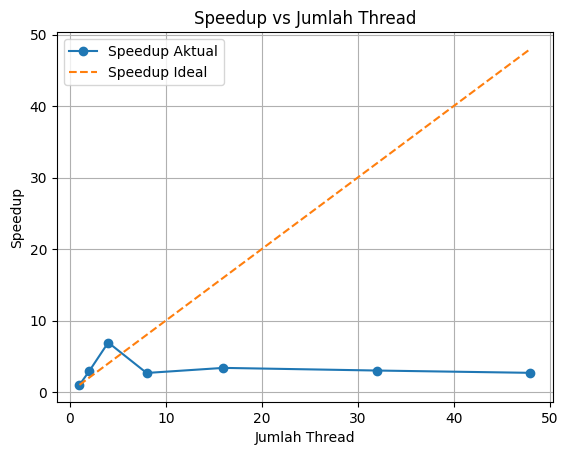

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(thread_counts, speedups, marker='o', label='Speedup Aktual')
plt.plot(thread_counts, thread_counts, linestyle='--', label='Speedup Ideal')

plt.xlabel('Jumlah Thread')
plt.ylabel('Speedup')
plt.title('Speedup vs Jumlah Thread')

plt.legend()
plt.grid()

plt.savefig('speedup_vs_thread.png')
plt.show()

## Efficiency vs Jumlah Thread

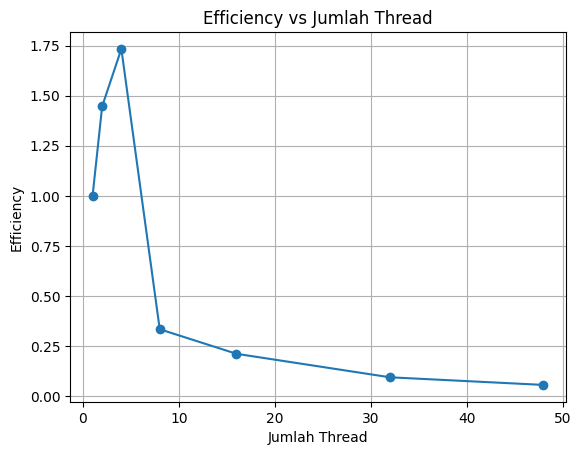

In [5]:
plt.figure()
plt.plot(thread_counts, efficiency, marker='o')

plt.xlabel('Jumlah Thread')
plt.ylabel('Efficiency')
plt.title('Efficiency vs Jumlah Thread')

plt.grid()

plt.savefig('efficiency_vs_thread.png')
plt.show()

## Waktu Eksekusi vs Thread

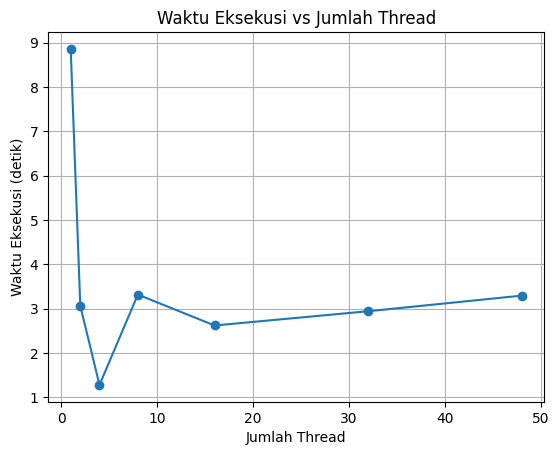

In [6]:
plt.figure()
plt.plot(thread_counts, times, marker='o')

plt.xlabel('Jumlah Thread')
plt.ylabel('Waktu Eksekusi (detik)')
plt.title('Waktu Eksekusi vs Jumlah Thread')

plt.grid()

plt.savefig('time_vs_thread.png')
plt.show()